# Clasificador de Calidad de Vinos con KNN

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## Paso 1: Cargar los datos

In [5]:
import pandas as pd

url = "https://raw.githubusercontent.com/4GeeksAcademy/k-nearest-neighbors-project-tutorial/refs/heads/main/winequality-red.csv"
df = pd.read_csv(url, sep=";")
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [6]:
def calidad_a_label(q):
    if q <= 4:
        return 0
    elif q <= 6:
        return 1
    else:
        return 2

df['label'] = df['quality'].apply(calidad_a_label)

## Paso 2: Preparar datos 

In [7]:
from sklearn.model_selection import train_test_split

x = df.drop(["label", "quality"], axis=1)
y = df["label"]

x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    random_state=42
)

## Paso 3: Escalar los datos

In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)


## Paso 4: Entrenar y Evaluar Modelo Inicial

In [9]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train_scaled, y_train)

y_pred = knn.predict(x_test_scaled)

print("Precisión:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Precisión: 0.84375
[[  0  11   0]
 [  1 250  11]
 [  0  27  20]]
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        11
           1       0.87      0.95      0.91       262
           2       0.65      0.43      0.51        47

    accuracy                           0.84       320
   macro avg       0.50      0.46      0.47       320
weighted avg       0.81      0.84      0.82       320



## Paso 5: Optimizar el valor de k(1-20)

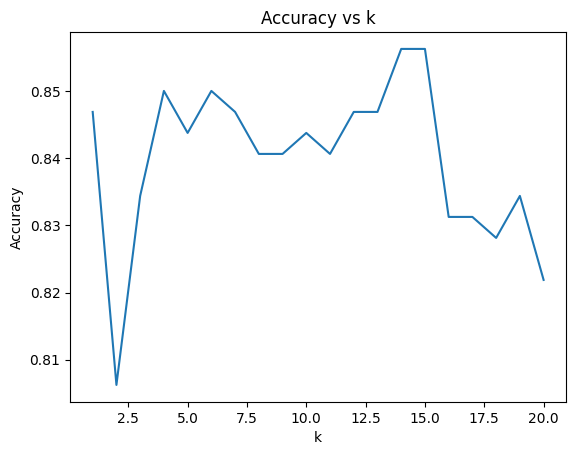

Mejor k: 14


In [10]:
import matplotlib.pyplot as plt

accuracies = []
k_values = range(1, 21)

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(x_train_scaled, y_train)
    y_pred = model.predict(x_test_scaled)
    accuracies.append(accuracy_score(y_test, y_pred))

best_k = k_values[accuracies.index(max(accuracies))]

plt.plot(k_values, accuracies)
plt.xlabel("k")
plt.ylabel("Accuracy")
plt.title("Accuracy vs k")
plt.show()

print("Mejor k:", best_k)

## Paso 6: Modelo final y funcion predictora

In [15]:
final_model = KNeighborsClassifier(n_neighbors=best_k)
final_model.fit(x_train_scaled, y_train)

def predict_wine_quality(features):
    features_scaled = scaler.transform([features])
    prediction = final_model.predict(features_scaled)[0]
    
    quality_map = {
        0: "Este vino probablemente sea de baja calidad 😕",
        1: "Este vino probablemente sea de calidad media 🍷",
        2: "Este vino probablemente sea de alta calidad 🏆"
    }
    
    return quality_map[prediction]



## Prueba


In [17]:
resultado = predict_wine_quality([7.4, 0.7, 0.0, 1.9, 0.076,
                                  11.0, 34.0, 0.9978, 3.51, 0.56, 9.4])
print("\nPredicción de ejemplo:", resultado)


Predicción de ejemplo: Este vino probablemente sea de calidad media 🍷


C:\Users\Farmatodo Kike\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
